# 4.데이터프레임 집계

- sum(), mean(), max(), min(), count() 메소드를 사용해 지정한 열 또는 열들을 기준으로 집계한다.
- 평균을 구하는 메소드가 avg()가 아닌 mean() 임을 주의하기 해야 한다.

- 데이터 집계에 대하여 아래와 같이 정리해 볼 수 있다.

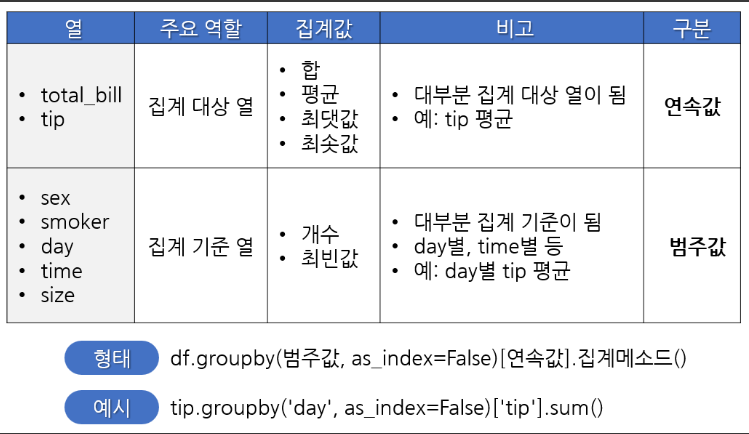


- **연속값**, **범주값**이라는 용어는 자주 등장한다.
- 대부분은 범주값을 기준으로 연속값의 합, 평균 등을 집계한다.
- 가끔은 범주값의 개수나 최빈값을 집계하기도 한다.
- 집계 결과에 대한 시각화를 통해 더 나은 통찰력을 얻기도 한다.

## 4.1.합 구하기

### 4.1.1.열 하나 집계

- 우선 특정 열의 값 합은 다음과 같이 구할 수 있다.

In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np

In [2]:
# 데이터 불러오기
path = './../00_data/tips.csv'
tips = pd.read_csv(path)

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# total_bill 합계
print(tips['total_bill'].sum())

4827.77


In [4]:
# total_bill 합계
print(tips[['total_bill', 'tip']].sum())

total_bill    4827.77
tip            731.58
dtype: float64


**1) 그룹별 집계하기; groupby()함수**
- 같은 값을 한 그룹으로 묶어서 여러 가지 연산 및 통계를 구할 수 있다.
- dataframe.groupby(by=grouping_columns)[columns_names].function()
    - dataframe : 대상 데이터프레임을 의미
    - by : 그룹화할 열을 지정하는 매개변수
    - grouping_columns : 그룹화할 열 이름 또는 열 이름의 리스트
    - columns_names : 집계 결과에서 표시할 열 이름 또는 열 이름의 리스트
    - function() : 적용할 집계 함수를 지정하는 함수


**2) 단일 그룹**

|함수|설명|
|:--|:--|
|count()|행의 갯수|
|nunique()|행의 유니크한 갯수|
|sum()|합|
|mean()|평균|
|min()|최솟값|
|max()|최댓값|
|std()|표준편차|
|var()|분산|

In [5]:
# 타이타닉 데이터 불러오기
path = './../00_data/titanic_train.csv'
ttc = pd.read_csv(path)

ttc.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
ttc.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
ttc.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# PassengerIdrk Int형으로 되어있어서, 평균을 구하거나 할때 계산됨. 이를 방지하고자 문자열로 변경
ttc['PassengerId'] = ttc['PassengerId'].astype(str)
ttc.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    str    
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(4), str(6)
memory usage: 83.7 KB


In [9]:
# Pclass 객실 등급에 따라 몇명이 탑습했는지
ttc.groupby('Pclass').count()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Pclass,,,,,,,,,,,
1,216,216,216,216,186,216,216,216,216,176,214
2,184,184,184,184,173,184,184,184,184,16,184
3,491,491,491,491,355,491,491,491,491,12,491


In [10]:
# numeric_only=True : 특정 열을 지정해주지 않고 숫자로 되어 있는 열만
ttc.groupby('Pclass').sum(numeric_only=True)

,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,
1,136,7111.42,90,77,18177.4125
2,87,5168.83,74,70,3801.8417
3,119,8924.92,302,193,6714.6951


In [ ]:
# 평균
ttc.groupby('Pclass').mean(numeric_only=True)

,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,
1,0.629630,38.233441,0.416667,0.356481,84.154687
2,0.472826,29.877630,0.402174,0.380435,20.662183
3,0.242363,25.140620,0.615071,0.393075,13.675550


In [ ]:
# 최솟값
ttc.groupby('Pclass').min(numeric_only=True)

,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,
1,0,0.92,0,0,0.0
2,0,0.67,0,0,0.0
3,0,0.42,0,0,0.0


In [13]:
# 최대값
ttc.groupby('Pclass').max(numeric_only=True)

,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,
1,1,80.0,3,4,512.3292
2,1,70.0,3,3,73.5000
3,1,74.0,8,6,69.5500


In [14]:
# 표준편차

ttc.groupby('Pclass').std(numeric_only=True)

,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,
1,0.484026,14.802856,0.611898,0.693997,78.380373
2,0.500623,14.001077,0.601633,0.690963,13.417399
3,0.428949,12.495398,1.374883,0.888861,11.778142


In [15]:
# 분산

ttc.groupby('Pclass').var(numeric_only=True)

,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,
1,0.234281,219.124543,0.374419,0.481632,6143.482816
2,0.250624,196.030152,0.361962,0.477429,180.026589
3,0.183998,156.134976,1.890303,0.790074,138.724622


In [18]:
# 객실 등급별 생존률
ttc.groupby('Pclass')[['Survived']].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [19]:
# 객실 등급별 생존률
ttc.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [20]:
# 객실 등급별 생존률
ttc.groupby('Pclass')[['Survived','Age']].mean()

,Survived,Age
Pclass,,
1,0.629630,38.233441
2,0.472826,29.877630
3,0.242363,25.140620


**3) 다중 그룹**

In [24]:
ttc.groupby(['Sex','Pclass']).mean(numeric_only=True)

Survived        Age     SibSp     Parch        Fare
Sex    Pclass                                                     
female 1       0.968085  34.611765  0.553191  0.457447  106.125798
       2       0.921053  28.722973  0.486842  0.605263   21.970121
       3       0.500000  21.750000  0.895833  0.798611   16.118810
male   1       0.368852  41.281386  0.311475  0.278689   67.226127
       2       0.157407  30.740707  0.342593  0.222222   19.741782
       3       0.135447  26.507589  0.498559  0.224784   12.661633

- **as_index=True**를 설정(기본값)하면 집계 기준이 되는 열이 인덱스 열이 된다.

In [ ]:
#day tip 합계 [] 괄화 1개면 시리즈 / [[]] 2개면 데이터프레임
tips.groupby(by='day', as_index=True)[['tip']].sum()

,tip
day,
Fri,51.96
Sat,260.40
Sun,247.39
Thur,171.83


In [ ]:
#series vs DataFrame

print(type(tips.groupby(by='day', as_index=True)[['tip']].sum()))
print(type(tips.groupby(by='day', as_index=True)['tip'].sum()))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


- **[['tip']].sum()** 과 같이 하면 열이 여럿이라는 의미여서 결과가 **데이터프레임** 이 된다.

In [32]:
tips.groupby(by='day', as_index=True)[['tip']].sum()

,tip
day,
Fri,51.96
Sat,260.40
Sun,247.39
Thur,171.83


- **as_index=False**를 설정하면 행 번호를 기반으로 한 정수 값이 인덱스로 설정된다.

In [33]:
tips.groupby(by='day', as_index=False)[['tip']].sum()

,day,tip
0,Fri,51.96
1,Sat,260.40
2,Sun,247.39
3,Thur,171.83


**4) 데이터프레임으로 선언**

- 집계 결과를 새로운 데이터프레임으로 선언하여 사용하는 경우가 많다.
- 집계된 결과를 반복해서 사용하거나, 분석 대상이 되는 경우 데이터프레임으로 선언함이 유익하다.

In [34]:
# day 별 tip 합계 조회
tips_sum = tips.groupby(by='day', as_index=False)[['tip']].sum()
tips_sum.head()

,day,tip
0,Fri,51.96
1,Sat,260.40
2,Sun,247.39
3,Thur,171.83


<Axes: >

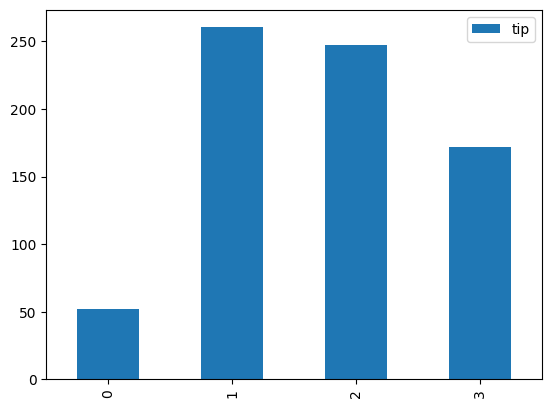

In [35]:
tips_sum.plot(kind='bar')

**5) 집계 결과 시각화**

- matplotlib 패키지의 pyplot을 plt 별칭을 주어 불러와 시각화에 사용한다.

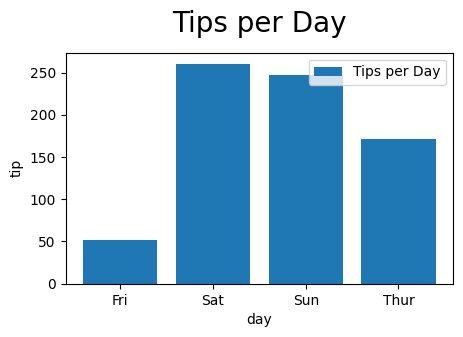

In [39]:
import matplotlib.pyplot as plt

#day 별 tip 비교 시각화
plt.figure(figsize=(5,3))
plt.bar(x=tips_sum['day'], height=tips_sum['tip'])
plt.title('Tips per Day', size=20, pad=15)

# 라벨
plt.xlabel('day')
plt.ylabel('tip')

# 범례 (legend) 추가
plt.legend(['Tips per Day'])

# 그래프 그리기
plt.show()

- plt.bar() 대신 plt.barh() 함수를 사용해 가로 막대그래프를 표시할 수 있다.

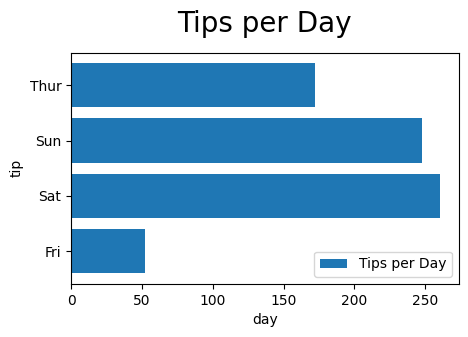

In [41]:
import matplotlib.pyplot as plt

#day 별 tip 비교 시각화
plt.figure(figsize=(5,3))
plt.barh(tips_sum['day'], tips_sum['tip'])
plt.title('Tips per Day', size=20, pad=15)

# 라벨
plt.xlabel('day')
plt.ylabel('tip')

# 범례 (legend) 추가
plt.legend(['Tips per Day'])

# 그래프 그리기
plt.show()

**6) 참고: 선 그래프**

- 연속형 값의 변화 추이를 볼 때 선 그래프가 유용하다.

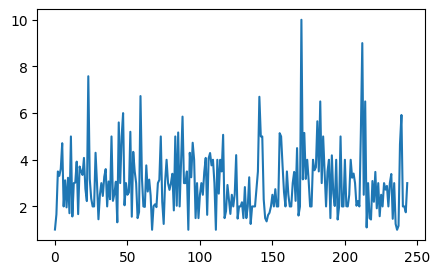

In [ ]:
# tip 변화 추이 시각화
tips_mean = tips['tip'].mean()

plt.figure(figsize=(5,3))

# tip 변환 추이 시각화(선그래프)
plt.plotW(tips['tip'])
plt.show()

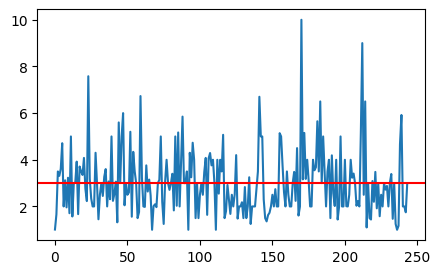

In [44]:
# tip 변화 추이 시각화
tips_mean = tips['tip'].mean()

plt.figure(figsize=(5,3))

# tip 변환 추이 시각화(선그래프)
plt.plot(tips['tip']) # 'tip' 열의 데이터를 순서대로 선 그래프로 그림

# 평균 팁을 나타내는 수평선 그리기
plt.axhline(tips_mean, color='r') # 평균 팁 값에 해당하는 위치에 빨간색 수평선을 그림
plt.show()

**7) 참고: 히스토그램**

- 연속형 값의 분포를 볼 때는 히스토그램이 유용하다.

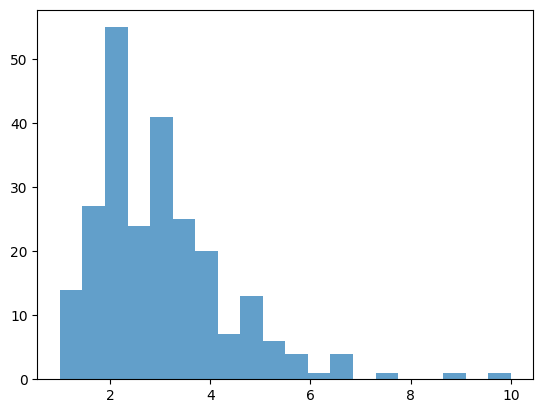

In [45]:
# tip 분포 시각화
plt.hist(tips['tip'], bins=20, alpha=0.7)
plt.show()

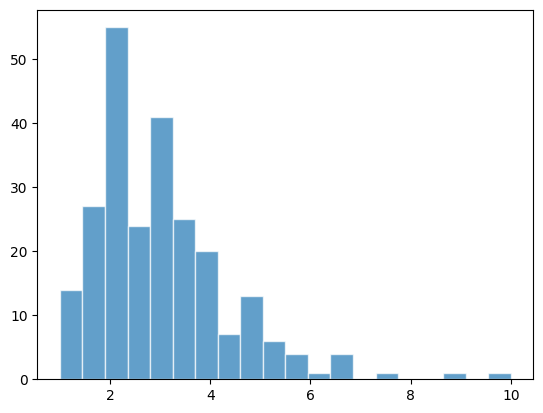

In [46]:
# tip 분포 시각화
plt.hist(tips['tip'], bins=20, alpha=0.7, edgecolor='w')
plt.show()

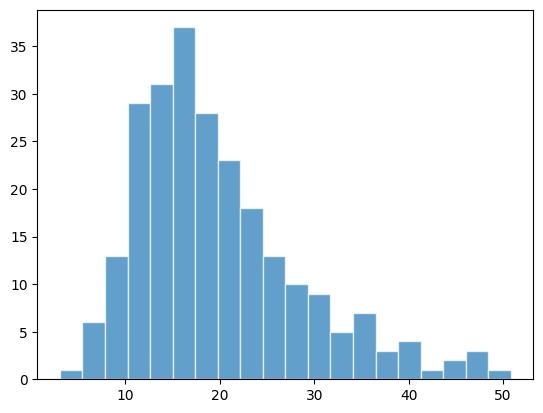

In [47]:
# total_bill 분포 시각화
plt.hist(tips['total_bill'], bins=20, alpha=0.7, edgecolor='w')
plt.show()

### 4.1.2.여러 열 집계

- 여러 열에 대한 집계를 같이 할 수 있다.
- **[ ['total_bill', 'tip'] ].sum()** 형태와 같이 집계 대상 열을 리스트로 지정한다.

In [52]:
tips_sum = tips.groupby(by='day', as_index=False)[['total_bill', 'tip']].sum()
tips_sum.head()

,day,total_bill,tip
0,Fri,325.88,51.96
1,Sat,1778.40,260.40
2,Sun,1627.16,247.39
3,Thur,1096.33,171.83


- sum() 메소드 앞에 아무 열도 지정하지 않으면 **기준열 이외의 모든 열에 대한 집계**가 수행된다.

In [53]:
tips_sum2 = tips.groupby(by='day', as_index=False).sum(numeric_only=True)
tips_sum2.head()

,day,total_bill,tip,size
0,Fri,325.88,51.96,40
1,Sat,1778.40,260.40,219
2,Sun,1627.16,247.39,216
3,Thur,1096.33,171.83,152


- **by=['day', 'smoker']** 과 같이 집계 기준 열을 여럿 설정할 수도 있다.

In [54]:
tips_sum3 = tips.groupby(by=['day', 'smoker'], as_index=False).sum(numeric_only=True)
tips_sum3.head()

,day,smoker,total_bill,tip,size
0,Fri,No,73.68,11.25,9
1,Fri,Yes,252.20,40.71,31
2,Sat,No,884.78,139.63,115
3,Sat,Yes,893.62,120.77,104
4,Sun,No,1168.88,180.57,167


In [55]:
tips_sum4 = tips.groupby(by=['day', 'smoker'], as_index=True).sum(numeric_only=True)
tips_sum4.head()

total_bill     tip  size
day smoker                          
Fri No           73.68   11.25     9
    Yes         252.20   40.71    31
Sat No          884.78  139.63   115
    Yes         893.62  120.77   104
Sun No         1168.88  180.57   167

- agg() 메소드로 다양한 집계

In [ ]:
# 열 하나에 대해 합계, 평균 등 집계를 한 번에 수행 가능
# day 별 tip  합계, 평균, 최대, 최소
tips.groupby('day')['tip'].agg(['sum',  'mean', 'max', 'min'])

,sum,mean,max,min
day,,,,
Fri,51.96,2.734737,4.73,1.00
Sat,260.40,2.993103,10.00,1.00
Sun,247.39,3.255132,6.50,1.01
Thur,171.83,2.771452,6.70,1.25


In [57]:
# 여러 열에 대해 여러 집계를 한번에 수행 가능

tips.groupby('day')[['total_bill', 'tip']].agg(['sum',  'mean'])

total_bill                tip          
            sum       mean     sum      mean
day                                         
Fri      325.88  17.151579   51.96  2.734737
Sat     1778.40  20.441379  260.40  2.993103
Sun     1627.16  21.410000  247.39  3.255132
Thur    1096.33  17.682742  171.83  2.771452

## 4.2.평균, 최댓값, 최솟값, 개수 구하기

- 위와 동일한 방법으로 평균, 최댓값, 최솟값, 개수를 집계할 수 있다.
- sum() 메소드 대신 관련된 메소드만 적절히 지정하면 된다.

**1) 평균 구하기**

In [60]:
# day 별 tip 평균
tip_mean = tips.groupby('day', as_index=False)[['tip']].mean()
tip_mean

,day,tip
0,Fri,2.734737
1,Sat,2.993103
2,Sun,3.255132
3,Thur,2.771452


In [61]:
# day + sex 별 tip 평균
tip_mean = tips.groupby(['day', 'sex'], as_index=False)[['tip']].mean()
tip_mean

,day,sex,tip
0,Fri,Female,2.781111
1,Fri,Male,2.693000
2,Sat,Female,2.801786
3,Sat,Male,3.083898
4,Sun,Female,3.367222
5,Sun,Male,3.220345
6,Thur,Female,2.575625
7,Thur,Male,2.980333


**2) 최댓값, 최솟값, 개수 구하기**


In [ ]:
# 최댓값
tip_max = tips.groupby('day')[['tip']].max()
tip_max

,tip
day,
Fri,4.73
Sat,10.00
Sun,6.50
Thur,6.70


In [ ]:
# 최솟값
tip_min = tips.groupby('day')[['tip']].min()
tip_min

,tip
day,
Fri,1.00
Sat,1.00
Sun,1.01
Thur,1.25


In [ ]:
# 개수 구하기
tip_count = tips.groupby('day')[['tip']].count()
tip_count

,tip
day,
Fri,19
Sat,87
Sun,76
Thur,62
